# Real flood footprints, not just points

The [companion notebook](flood_events_and_footprints.ipynb) used `gdis:points` — one centroid per affected
administrative unit. Centroids are cheap and answer *where roughly*. They cannot answer *how much area*, *which
of my parcels intersect*, or *what land cover was inundated*, because a point has no extent.

`gdis:polygons` carries the actual administrative-unit geometry. This notebook shows what that buys you, and
what it costs.

> **This notebook downloads 2.2 GB.** The GDIS GeoPackage is 2.2 GB compressed and 6.3 GB on disk — about 2000×
> the centroid CSV. Run it only when you need real geometry. earthlens warns before it starts, keeps the granule
> in your output directory, and reuses it on later calls.

Two things make this workable rather than painful:

* **The filters are pushed down into the driver.** Hazard, country and bounding box become an OGR attribute and
  spatial filter, so a regional query reads a handful of features out of a 6.3 GB file rather than loading it.
* **The date window is not.** The GeoPackage has no date column at all — the year lives in the 4-digit prefix of
  `disasterno` — so earthlens applies that filter in memory after the read. It is the one filter that does not
  save you I/O here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from earthlens.core import EarthLens

OUT = Path("_emdat_output")
OUT.mkdir(exist_ok=True)

BANGLADESH_LAT = [20.5, 26.7]
BANGLADESH_LON = [88.0, 92.7]

## 1. Fetch the footprints

Identical to the centroid request bar the dataset id. The first call downloads the granule; later calls reuse
it.

In [2]:
footprints = EarthLens(
    "emdat",
    variables=["gdis:polygons"],
    start="1990-01-01",
    end="2018-12-31",
    hazard="flood",
    lat_lim=BANGLADESH_LAT,
    lon_lim=BANGLADESH_LON,
    path=str(OUT),
).download()

print(f"{len(footprints)} footprints, geometry {set(footprints.geometry.geom_type)}")
print(f"{footprints['disasterno'].nunique()} distinct flood events")

562 footprints, geometry {'MultiPolygon'}
131 distinct flood events


## 2. What a polygon shows that a point cannot

Fetching the same request as centroids and drawing both together makes the difference concrete: each point sits
inside a real administrative unit whose size varies by orders of magnitude.

In [3]:
centroids = EarthLens(
    "emdat",
    variables=["gdis:points"],
    start="1990-01-01",
    end="2018-12-31",
    hazard="flood",
    lat_lim=BANGLADESH_LAT,
    lon_lim=BANGLADESH_LON,
    path=str(OUT),
).download()

print(f"{len(centroids)} centroids vs {len(footprints)} footprints")

442 centroids vs 562 footprints


The two counts differ — 562 footprints against 442 centroids — and the reason is worth knowing. A bounding box selects a **point** only if the point falls inside it, but selects a **polygon** if the polygon *intersects* it. Border districts whose centroid sits outside the box are therefore in the polygon result and absent from the centroid one. Neither is wrong; they answer slightly different questions, and the polygon answer is the one you want when the box is a real study area.


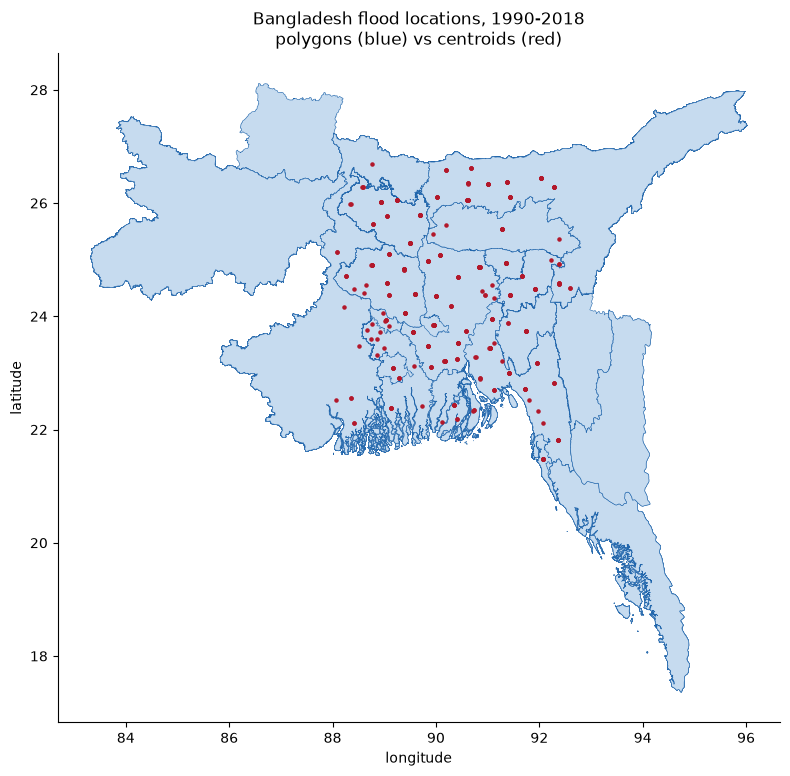

In [4]:
fig, ax = plt.subplots(figsize=(8, 9))
footprints.plot(ax=ax, facecolor="#c6dbef", edgecolor="#2166ac", linewidth=0.4)
centroids.plot(ax=ax, color="#b2182b", markersize=5)
ax.set_title(
    "Bangladesh flood locations, 1990-2018\npolygons (blue) vs centroids (red)"
)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

The red dots are what the cheap dataset gives you. The blue shapes are what actually flooded. Notice how
uneven the units are — a centroid in a large district and one in a small sub-district look identical, but the
areas behind them differ by a factor of a hundred.

## 3. Area — the thing only polygons can answer

A caveat that bites people: **`.area` on lon/lat degrees is meaningless.** Degrees are not a unit of area, and
a degree of longitude shrinks towards the poles. Reproject to an equal-area or local projected CRS first.
`estimate_utm_crs()` picks the right UTM zone for the data's own extent.

In [5]:
metric = footprints.to_crs(footprints.estimate_utm_crs())
footprints["area_km2"] = metric.area / 1e6

biggest = footprints.nlargest(8, "area_km2")[["adm1", "adm2", "disasterno", "area_km2"]]
print(
    f"total flooded admin area (with repeats): {footprints['area_km2'].sum():,.0f} km2"
)
biggest

total flooded admin area (with repeats): 8,441,385 km2


,adm1,adm2,disasterno,area_km2
533,Bihar,None,1997-0260,94234.557545
538,Bihar,None,1998-0392,94234.557545
539,Bihar,None,1999-0371,94234.557545
541,Bihar,None,2001-0465,94234.557545
546,Bihar,None,2009-0409,94234.557545
439,Bihar,None,1991-0532,94232.106803
441,Bihar,None,1995-0228,94232.106803
444,Bihar,None,1996-0501,94232.106803


## 4. How often each area floods, weighted by size

With geometry you can dissolve the repeated footprints into a per-unit picture: how many distinct flood events
touched each administrative unit, and how large that unit is. A points-only dataset can count events but cannot
tell you the second half.

In [6]:
per_unit = (
    footprints.dissolve(
        by="adm2", aggfunc={"disasterno": "nunique", "area_km2": "first"}
    )
    .rename(columns={"disasterno": "events"})
    .sort_values("events", ascending=False)
)
print(f"{len(per_unit)} distinct administrative units")
per_unit[["events", "area_km2"]].head(8)

88 distinct administrative units


,events,area_km2
adm2,,
Gaibandha,15,2171.369551
Sunamganj,15,3737.454600
Cox'S Bazar,14,2151.000864
Bogra,14,2893.723876
Sirajganj,14,2442.494862
Kurigram,13,2269.597116
Habiganj,11,2590.986471
Mechi,11,1607.061854


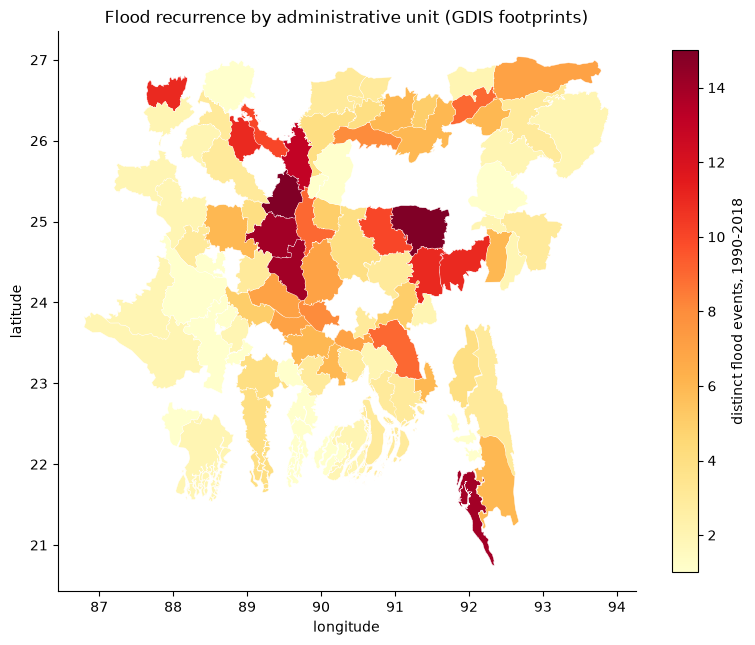

In [7]:
fig, ax = plt.subplots(figsize=(8, 9))
per_unit.plot(
    ax=ax,
    column="events",
    cmap="YlOrRd",
    edgecolor="white",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "distinct flood events, 1990-2018", "shrink": 0.6},
)
ax.set_title("Flood recurrence by administrative unit (GDIS footprints)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

That map is the payoff. It is a choropleth of real administrative units — not interpolated from points —
so every boundary is where the source says the flood was recorded.

## 5. The resolution is uneven, and the data says so

GDIS records each location at whatever administrative level it could geocode. `level` tells you which, and it
matters: a level-1 footprint is a whole province, a level-3 one is a village. Treating them as equivalent will
skew any area statistic.

In [8]:
by_level = footprints.groupby("level").agg(
    footprints=("disasterno", "size"), median_km2=("area_km2", "median")
)
print(by_level.to_string())
print("\nlevel 1 = province/state, 2 = district, 3 = sub-district/village")

       footprints    median_km2
level                          
1             127  79085.972620
2             401   2254.686023
3              34    354.405849

level 1 = province/state, 2 = district, 3 = sub-district/village


## When to use which

| You need | Use | Cost |
|---|---|---|
| Where a disaster happened, roughly | `gdis:points` | 1.09 MB |
| Impact figures (deaths, affected, damage) | `emdat:events` | 8 MB, anonymous |
| Area, intersection, zonal statistics, choropleths | `gdis:polygons` | **2.2 GB** |

Reach for the polygons only for the third row. If you are joining to impact figures, plotting locations, or
counting events, the centroids do the job for a two-thousandth of the download.

Both GDIS datasets stop at **2018** and cover **natural hazards only** — see the
[introduction](../../reference/emdat/introduction.md) for the full caveats and the licence terms.

### Citation

Rosvold, E.L. & Buhaug, H. (2021). GDIS, a global dataset of geocoded disaster locations. *Scientific Data* 8,
61. NASA SEDAC, DOI `10.7927/61jv-th84`.